In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

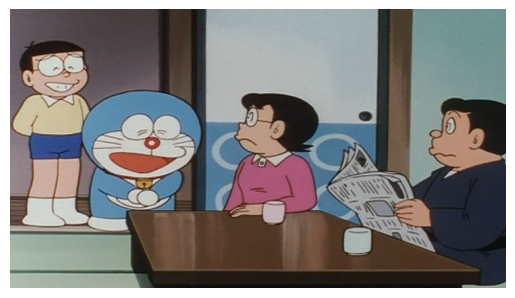

In [37]:
img = cv2.imread('doraemon.jpg')
img_rgb=img[:,:,::-1]
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

# Chuyển ảnh sang ảnh xám

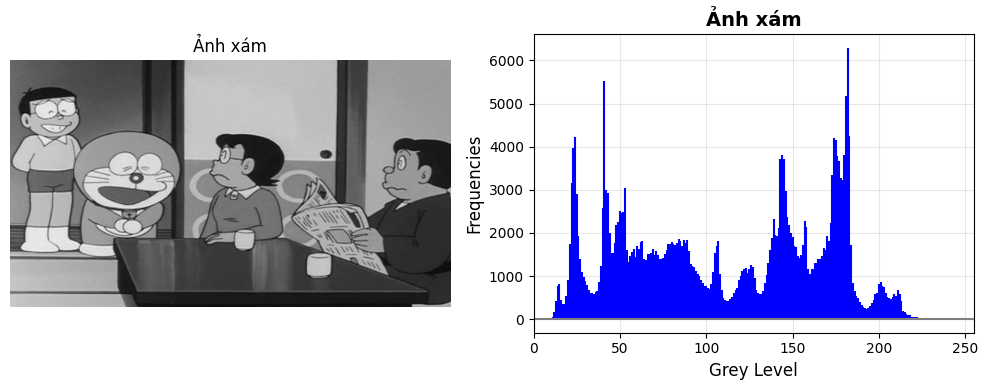

In [38]:
img_gray = cv2.cvtColor(img_rgb,cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_gray,cmap='gray')
plt.title('Ảnh xám')
plt.axis('off')

hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])
plt.subplot(1, 2, 2)
grey_levels = np.arange(256)
plt.stem(grey_levels, hist.flatten(), linefmt='blue', markerfmt='', basefmt='grey')
plt.title('Ảnh xám', fontsize=14, fontweight='bold')
plt.xlabel('Grey Level', fontsize=12)
plt.ylabel('Frequencies', fontsize=12)
plt.xlim([0, 255])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cân bằng Histogram

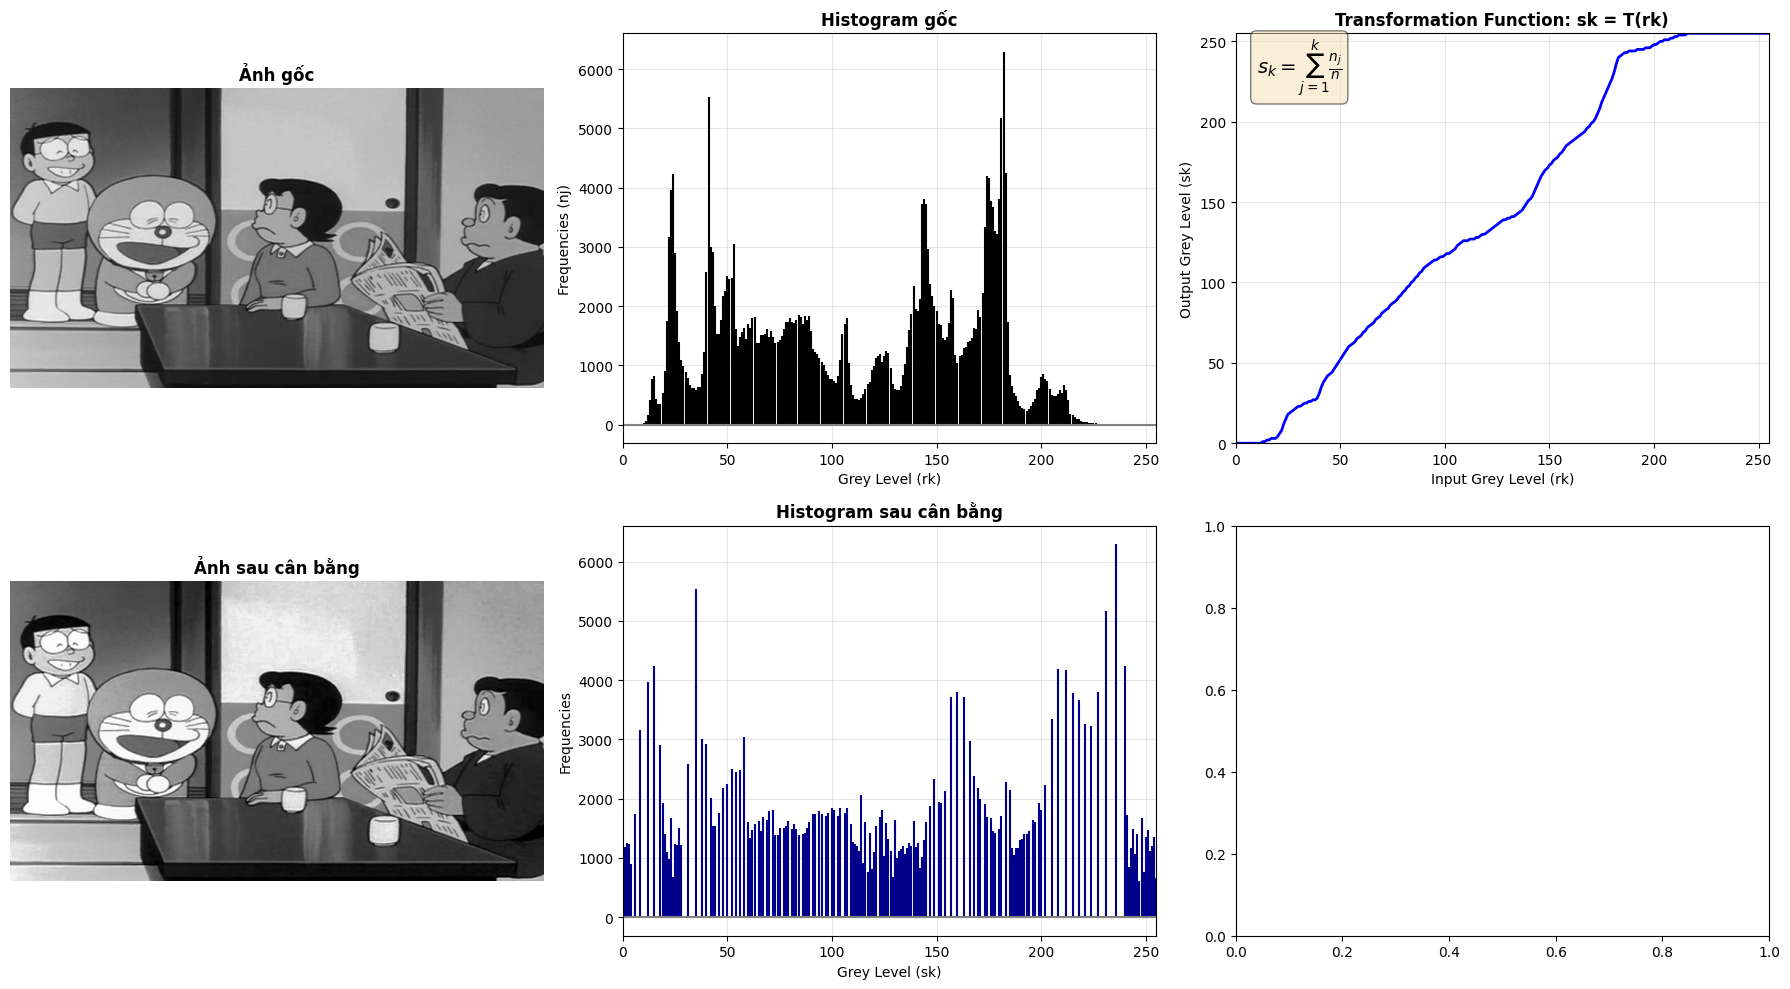

In [39]:
h,w=img_gray.shape
hist_original = np.zeros(256)
for i in range(h):
    for j in range(w):
        intensity = img_gray[i, j]
        hist_original[intensity] += 1
n=h*w
pdf=hist_original/n
cdf=np.zeros(256)
cdf[0]=pdf[0]
for k in range(1,256):
    cdf[k] = cdf[k-1]+pdf[k]
transformation = np.round(cdf * 255).astype(np.uint8) #Scale CDF về khoảng [0,255]

# Áp dụng transformation cho từng pixel
img_equalized = np.zeros_like(img_gray)
for i in range(h):
    for j in range(w):
        old_intensity = img_gray[i, j]
        new_intensity = transformation[old_intensity]
        img_equalized[i, j] = new_intensity

# tính histogram sau khi cân bằng

hist_equalized = np.zeros(256)
for i in range(h):
    for j in range(w):
        intensity = img_equalized[i, j]
        hist_equalized[intensity] += 1

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title('Ảnh gốc', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')
# Hàng 1: Histogram gốc
axes[0, 1].stem(np.arange(256), hist_original, 
                linefmt='black', markerfmt=' ', basefmt='grey')
axes[0, 1].set_title('Histogram gốc', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Grey Level (rk)')
axes[0, 1].set_ylabel('Frequencies (nj)')
axes[0, 1].set_xlim([0, 255])
axes[0, 1].grid(True, alpha=0.3)
# Hàng 1: Transformation Function (CDF)
axes[0, 2].plot(np.arange(256), transformation, 'b-', linewidth=2)
axes[0, 2].set_title('Transformation Function: sk = T(rk)', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Input Grey Level (rk)')
axes[0, 2].set_ylabel('Output Grey Level (sk)')
axes[0, 2].set_xlim([0, 255])
axes[0, 2].set_ylim([0, 255])
axes[0, 2].grid(True, alpha=0.3)
# Thêm công thức
axes[0, 2].text(10, 230, r'$s_k = \sum_{j=1}^{k} \frac{n_j}{n}$', 
                fontsize=14, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
# Hàng 2: Ảnh sau cân bằng
axes[1, 0].imshow(img_equalized, cmap='gray')
axes[1, 0].set_title('Ảnh sau cân bằng', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')
# Hàng 2: Histogram sau cân bằng
axes[1, 1].stem(np.arange(256), hist_equalized, 
                linefmt='darkblue', markerfmt=' ', basefmt='grey')
axes[1, 1].set_title('Histogram sau cân bằng', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Grey Level (sk)')
axes[1, 1].set_ylabel('Frequencies')
axes[1, 1].set_xlim([0, 255])
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()





## Ảnh đảo

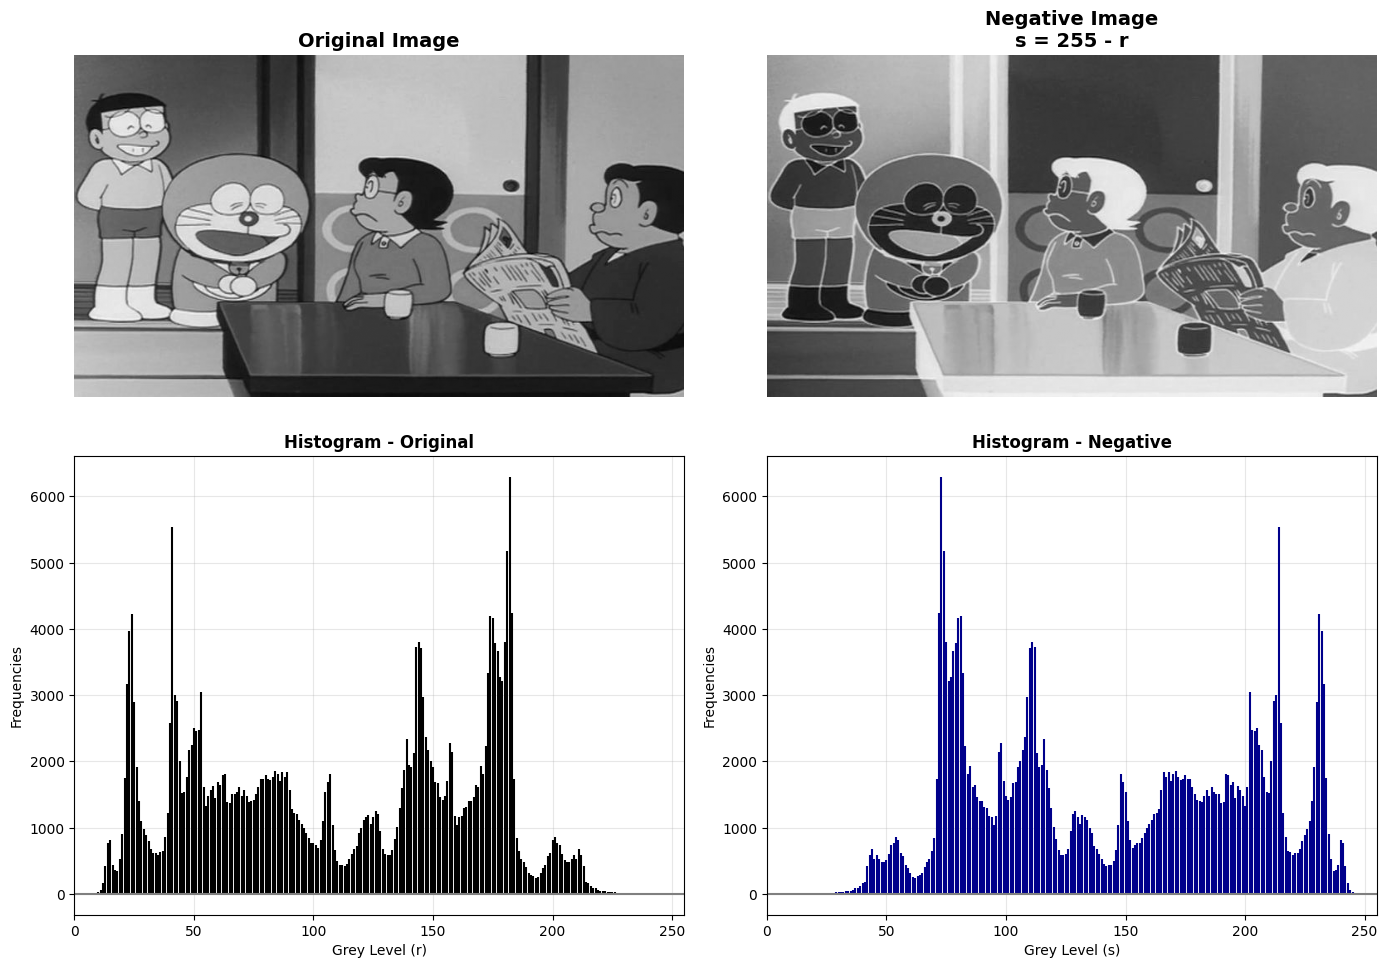

In [40]:
img_negative = 255 - img_gray
hist_negative = cv2.calcHist([img_negative], [0], None, [256], [0, 256]) #tính histogram của ảnh

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Ảnh gốc
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')
# Ảnh đảo (negative)
axes[0, 1].imshow(img_negative, cmap='gray')
axes[0, 1].set_title('Negative Image\ns = 255 - r', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')
# Histogram ảnh gốc
axes[1, 0].stem(np.arange(256), hist_original.flatten(), 
                linefmt='black', markerfmt=' ', basefmt='grey')
axes[1, 0].set_title('Histogram - Original', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Grey Level (r)')
axes[1, 0].set_ylabel('Frequencies')
axes[1, 0].set_xlim([0, 255])
axes[1, 0].grid(True, alpha=0.3)
# Histogram ảnh đảo
axes[1, 1].stem(np.arange(256), hist_negative.flatten(), 
                linefmt='darkblue', markerfmt=' ', basefmt='grey')
axes[1, 1].set_title('Histogram - Negative', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Grey Level (s)')
axes[1, 1].set_ylabel('Frequencies')
axes[1, 1].set_xlim([0, 255])
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cắt ngưỡng

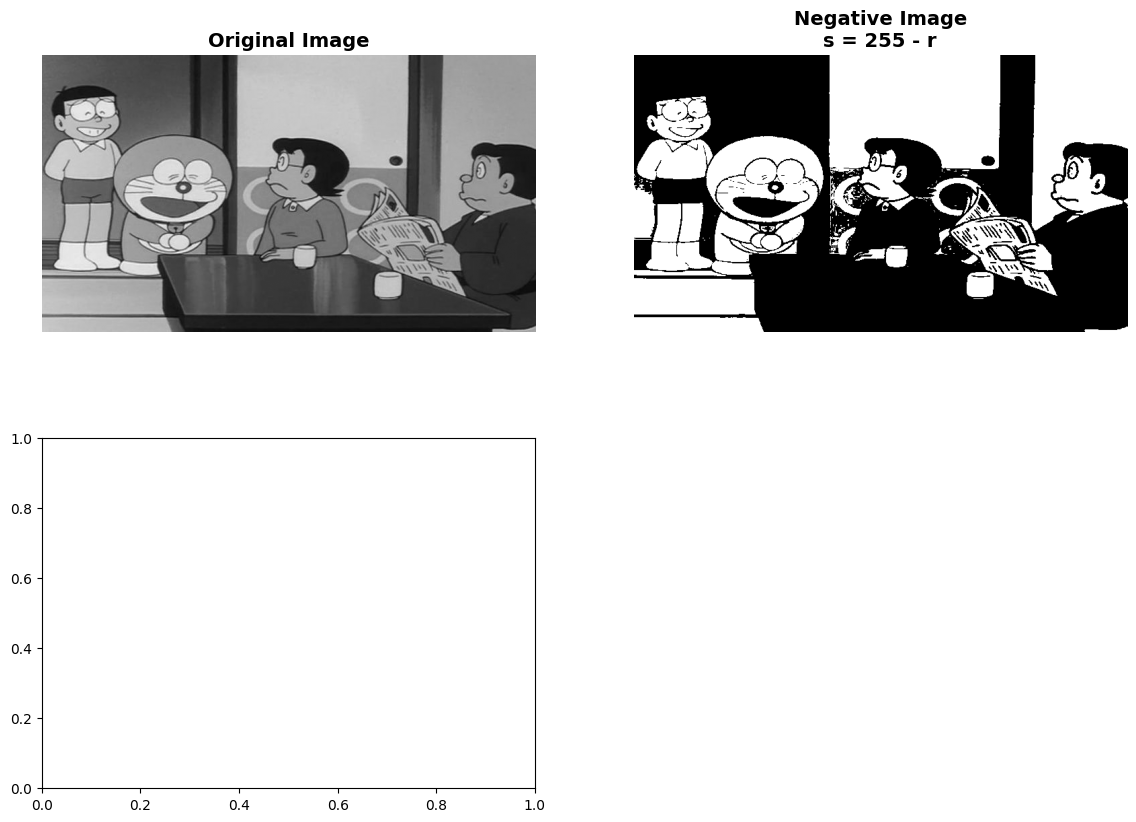

In [41]:
threshold = 127
img_threshold = np.where(img_gray > threshold, 255, 0).astype(np.uint8)
cv2.calcHist([img_threshold], [0], None, [256], [0, 256])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Ảnh gốc
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')
# Ảnh nhị phân 
axes[0, 1].imshow(img_threshold, cmap='gray')
axes[0, 1].set_title('Negative Image\ns = 255 - r', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')
plt.axis('off')
plt.show()

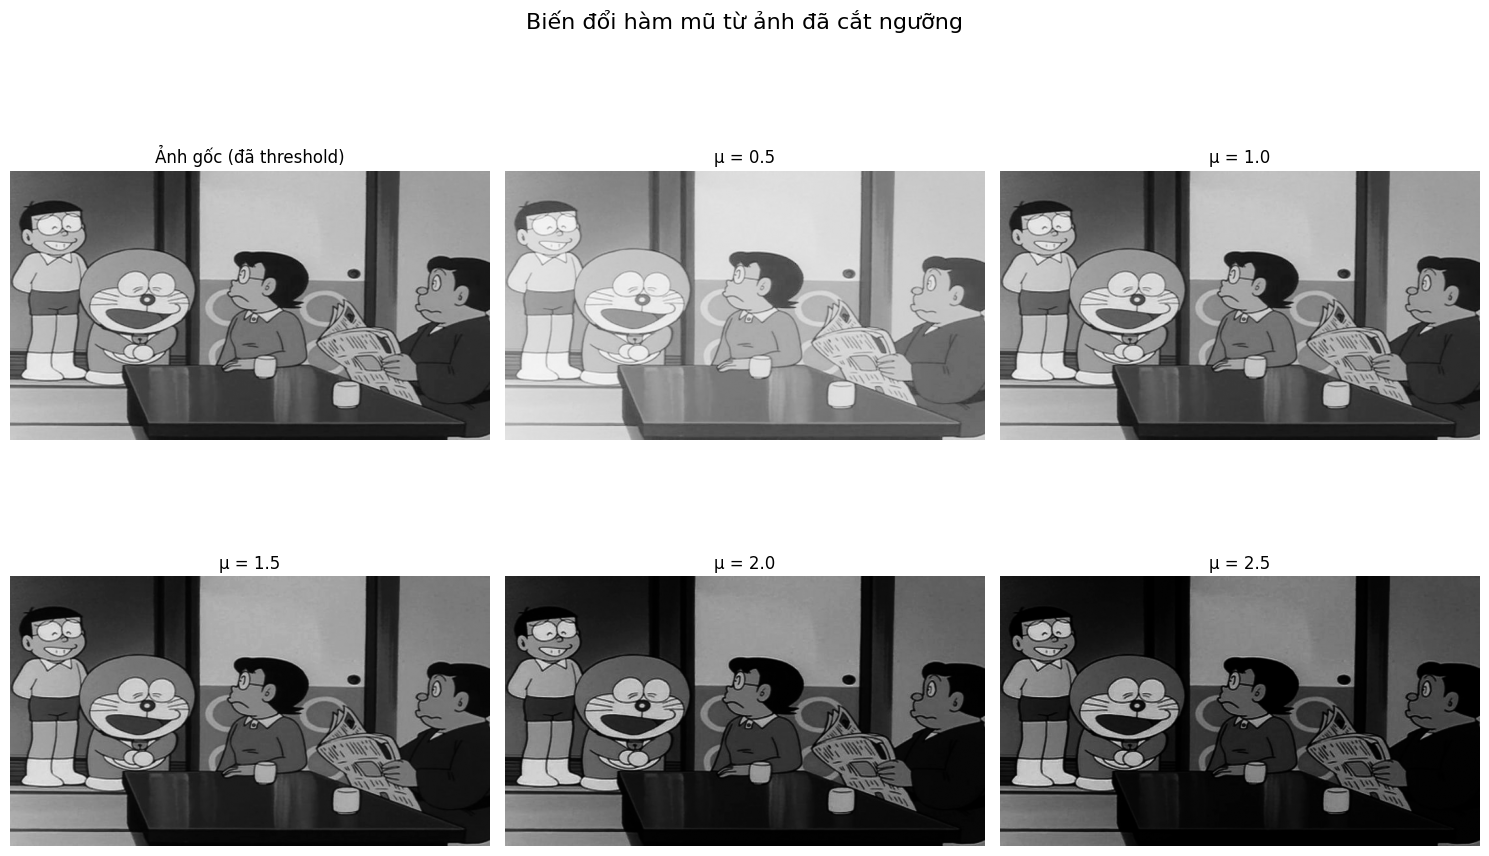

In [42]:
# Chuẩn hóa về khoảng [0, 1]
normalized = img_gray / 255.0
# Tạo các ảnh với biến đổi hàm mũ với các giá trị μ (gamma) khác nhau
gamma_values = [0.5, 1.0, 1.5, 2.0, 2.5]
transformed_images = []
for gamma in gamma_values:
    # Áp dụng công thức: s = r^μ
    transformed = np.power(normalized, gamma)
    # Chuyển về khoảng [0, 255]
    transformed = np.uint8(transformed * 255)
    transformed_images.append(transformed)
# Hiển thị kết quả
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Biến đổi hàm mũ từ ảnh đã cắt ngưỡng', fontsize=16)
# Hiển thị ảnh gốc đã threshold
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title('Ảnh gốc (đã threshold)')
axes[0, 0].axis('off')
# Hiển thị các ảnh đã biến đổi
for idx, (gamma, transformed) in enumerate(zip(gamma_values, transformed_images)):
    row = (idx + 1) // 3
    col = (idx + 1) % 3
    axes[row, col].imshow(transformed, cmap='gray')
    axes[row, col].set_title(f'μ = {gamma}')
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

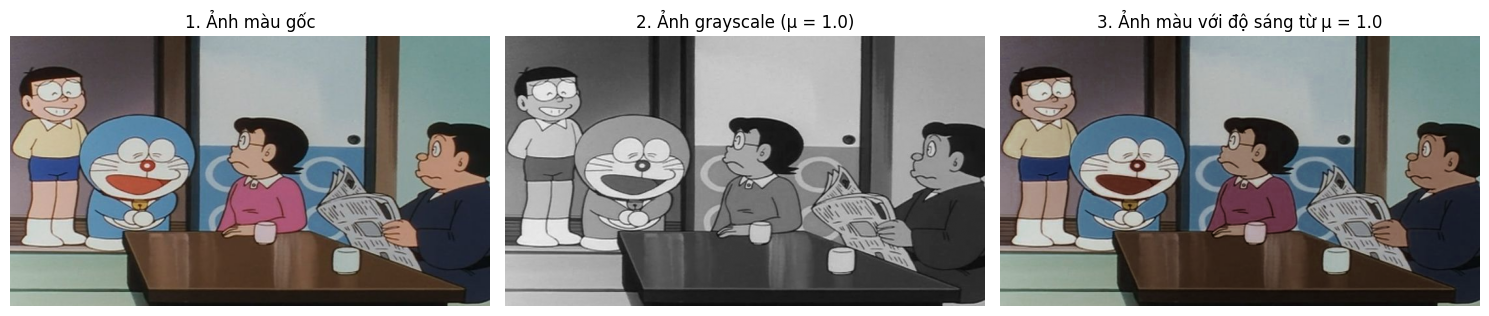

In [43]:
# Đọc ảnh màu gốc
img_color = cv2.imread('doraemon.jpg')
img_color_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

# Chọn ảnh đã biến đổi 
gamma_index = 1  # μ = 1
gamma_value = gamma_values[gamma_index]
img_transformed_gray = transformed_images[gamma_index]

# Chuyển ảnh màu gốc sang HSV
img_hsv = cv2.cvtColor(img_color, cv2.COLOR_BGR2HSV)

# Tách các kênh H, S, V
h, s, v = cv2.split(img_hsv)

# Thay kênh V (Value/độ sáng) bằng ảnh grayscale đã biến đổi
v_new = img_transformed_gray

# Ghép lại các kênh
img_hsv_new = cv2.merge([h, s, v_new])

# Chuyển về RGB
img_color_transformed = cv2.cvtColor(img_hsv_new, cv2.COLOR_HSV2RGB)

# Hiển thị kết quả
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_color_rgb)
axes[0].set_title('1. Ảnh màu gốc')
axes[0].axis('off')

axes[1].imshow(img_transformed_gray, cmap='gray')
axes[1].set_title(f'2. Ảnh grayscale (μ = {gamma_value})')
axes[1].axis('off')

axes[2].imshow(img_color_transformed)
axes[2].set_title(f'3. Ảnh màu với độ sáng từ μ = {gamma_value}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

